# WHy oh why is my ssh going unstable

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cmocean as cm
import gsw
import datetime as dt
import pandas as pd
from salishsea_tools.LiveOcean_BCs import convect, stabilize
import copy

In [2]:
err = xr.open_dataset("/ocean/rbeutel/MOAD/analysis-becca/projections/output.abort_original.nc")
err

<xarray.Dataset> Size: 413MB
Dimensions:       (time_counter: 1, deptht: 40, y: 898, x: 398)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 8B 2019-02-19T00:00:40
  * deptht        (deptht) float32 160B 0.5 1.5 2.5 3.5 ... 387.6 414.5 441.5
    nav_lon       (y, x) float32 1MB ...
    nav_lat       (y, x) float32 1MB ...
Dimensions without coordinates: y, x
Data variables: (12/14)
    vosaline      (time_counter, deptht, y, x) float32 57MB ...
    votemper      (time_counter, deptht, y, x) float32 57MB ...
    sossheig      (time_counter, y, x) float32 1MB ...
    vozocrtx      (time_counter, deptht, y, x) float32 57MB ...
    vomecrty      (time_counter, deptht, y, x) float32 57MB ...
    vovecrtz      (time_counter, deptht, y, x) float32 57MB ...
    ...            ...
    soshfldo      (time_counter, y, x) float32 1MB ...
    soicecov      (time_counter, y, x) float32 1MB ...
    sozotaux      (time_counter, y, x) float32 1MB ...
    sometauy      (time_counter, y, x) float32 1MB ...
    vovvldep      (time_counter, deptht, y, x) float32 57MB ...
    vovvle3t      (time_counter, deptht, y, x) float32 57MB ...
Attributes:
    Conventions:  CF-1.1
    production:   An IPSL model
    TimeStamp:    30/06/2026 00:31:16 -0700
    file_name:    output.abort.nc

In [3]:
ssh = err.sossheig.values[0,:,:]
ssh

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(898, 398), dtype=float32)

In [4]:
print(np.nanmax(ssh))
print(np.argmax(ssh))

2.0403836
154426


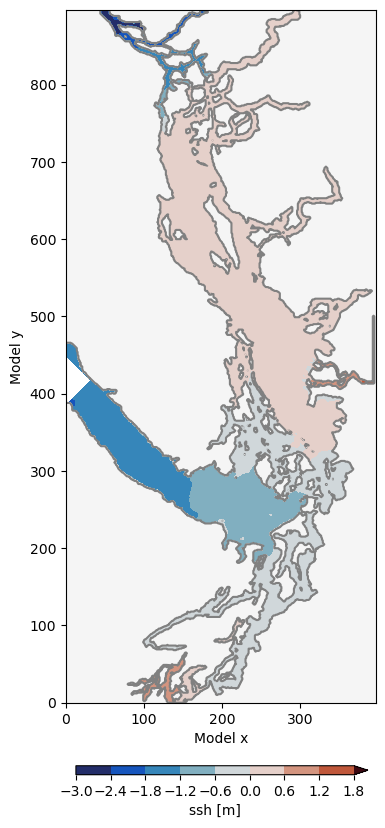

In [5]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask201702.nc')
grid = xr.open_dataset("/home/sallen/MEOPAR/grid/bathymetry_202108.nc", mask_and_scale=False)

# Make plot area
fig, ax = plt.subplots(figsize=(4, 9))

# Depth
c = ax.contourf(
    grid.x, grid.y, ssh, vmax=3, vmin=-3,
    cmap=cm.cm.balance, extend='max', zorder=1,
)
cax = fig.add_axes([0.15, 0.03, 0.73, 0.01])
fig.colorbar(c, cax=cax, orientation='horizontal',label='ssh [m]')

ax.set_xlabel("Model x")
ax.set_ylabel("Model y")

# Draw coastline
ax.contourf(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='whitesmoke')
ax.contour(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='gray')

## look at the boundary files

In [6]:
data = xr.open_dataset("/ocean/rbeutel/MOAD/analysis-becca/projections/output/bdy_AllChange/LiveOcean_v201905_y2019m02d17.nc")

# build an easily editable tracer dictionary 
day17 = {
    "salt":       data["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
    "temp":       data["votemper"][0, :, :, :].values.copy(),
}

data = xr.open_dataset("/ocean/rbeutel/MOAD/analysis-becca/projections/output/bdy_AllChange/LiveOcean_v201905_y2019m02d18.nc")

# build an easily editable tracer dictionary 
day18 = {
    "salt":       data["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
    "temp":       data["votemper"][0, :, :, :].values.copy(),
}

data = xr.open_dataset("/ocean/rbeutel/MOAD/analysis-becca/projections/output/bdy_AllChange/LiveOcean_v201905_y2019m02d19.nc")

# build an easily editable tracer dictionary 
day19 = {
    "salt":       data["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
    "temp":       data["votemper"][0, :, :, :].values.copy(),
}

In [7]:
# add density

day17['sigma0'] = gsw.density.sigma0(day17['salt'],day17['temp'])
day18['sigma0'] = gsw.density.sigma0(day18['salt'],day18['temp'])
day19['sigma0'] = gsw.density.sigma0(day19['salt'],day19['temp'])

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

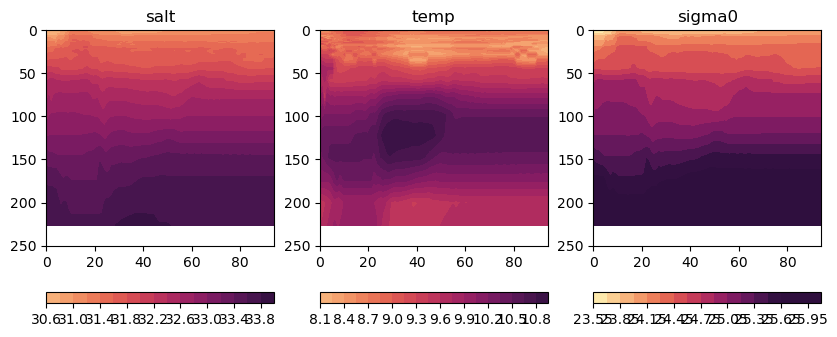

In [8]:
# day 17 (2 days before failure)
# looks at a section for each edited variable
X, Y = np.meshgrid(data.xbT[0:95].values,data.deptht.values)
tracers = ['salt','temp','sigma0']
vmin = [30,7.6,23.6]
vmax = [34,11,25.6]

fig, ax = plt.subplots(1,3,figsize=[10,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}"
    ax[i].set_title(title)

    values = day17[tracers[i]][:,0,0:95]

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.matter,vmin=vmin[i],vmax=vmax[i])
    fig.colorbar(cs, ax=ax[i], location='bottom')
    ax[i].set_ylim([250,0])

plt.tight_layout

# properties in expected direction and focused in the surface :) 


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

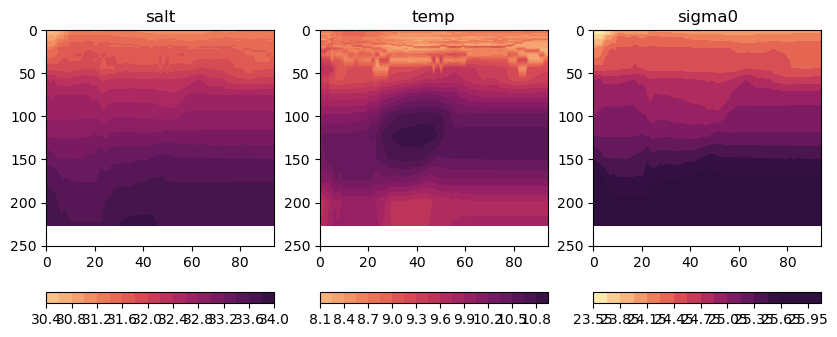

In [9]:
# day 18 (day before failure)
# looks at a section for each edited variable
X, Y = np.meshgrid(data.xbT[0:95].values,data.deptht.values)
tracers = ['salt','temp','sigma0']
vmin = [30,7.6,23.6]
vmax = [34,11,25.6]

fig, ax = plt.subplots(1,3,figsize=[10,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}"
    ax[i].set_title(title)

    values = day18[tracers[i]][:,0,0:95]

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.matter,vmin=vmin[i],vmax=vmax[i])
    fig.colorbar(cs, ax=ax[i], location='bottom')
    ax[i].set_ylim([250,0])

plt.tight_layout

# properties in expected direction and focused in the surface :) 


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

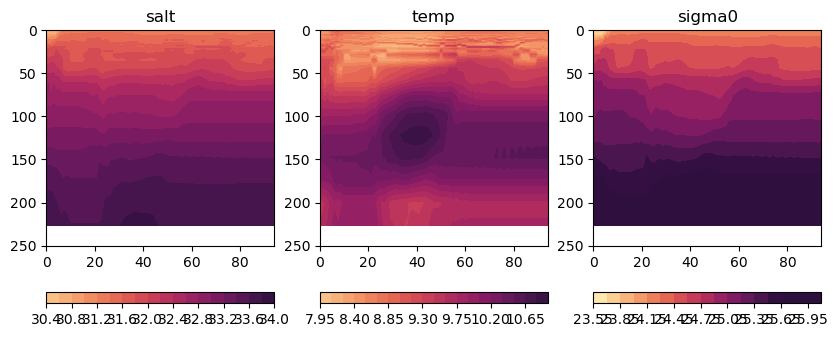

In [10]:
# day 19
# looks at a section for each edited variable
X, Y = np.meshgrid(data.xbT[0:95].values,data.deptht.values)
tracers = ['salt','temp','sigma0']
vmin = [30,7.6,23.6]
vmax = [34,11,25.6]

fig, ax = plt.subplots(1,3,figsize=[10,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}"
    ax[i].set_title(title)

    values = day19[tracers[i]][:,0,0:95]

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.matter,vmin=vmin[i],vmax=vmax[i])
    fig.colorbar(cs, ax=ax[i], location='bottom')
    ax[i].set_ylim([250,0])

plt.tight_layout

# properties in expected direction and focused in the surface :) 


## thalweg

In [11]:
from salishsea_tools import visualisations as vis
import netCDF4 as nc

In [12]:
change = xr.open_dataset('/ocean/rbeutel/MOAD/analysis-becca/projections/output/SalishSea_1d_20180101_20181231_grid_T_20180420-20180420.nc')
old = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/20apr18/SalishSea_1d_20180420_20180420_grid_T.nc')

In [13]:
bathy = nc.Dataset("/home/sallen/MEOPAR/grid/bathymetry_202108.nc")
mesh = nc.Dataset('/home/sallen/MEOPAR/grid/mesh_mask201702.nc')
thalweg_in = '/home/sallen/MEOPAR/Tools/bathymetry/thalweg_working.txt'

Text(0.5, 1.0, '202111')

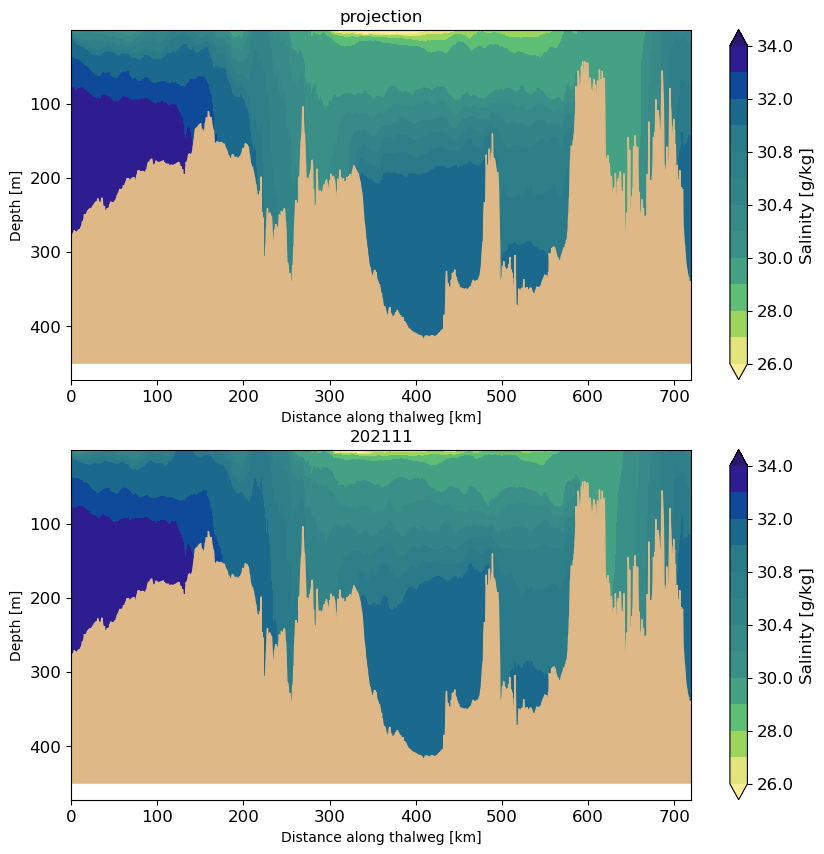

In [14]:
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(10,10))

#CHANGE
tit = 'projection'
data_to_plot = change['vosaline'].isel(time_counter=0).values

cbar = vis.contour_thalweg(ax1, data_to_plot, bathy, mesh, clevels='salinity', cmap = cm.cm.haline_r, thalweg_file=thalweg_in)
cbar.set_label('Salinity [g/kg]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title(tit)

#original
tit = '202111'

data_to_plot = old['vosaline'].isel(time_counter=0).values

cbar = vis.contour_thalweg(ax2, data_to_plot, bathy, mesh, clevels='salinity', cmap = cm.cm.haline_r, thalweg_file=thalweg_in)
cbar.set_label('Salinity [g/kg]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title(tit)

Text(0.5, 1.0, '202111')

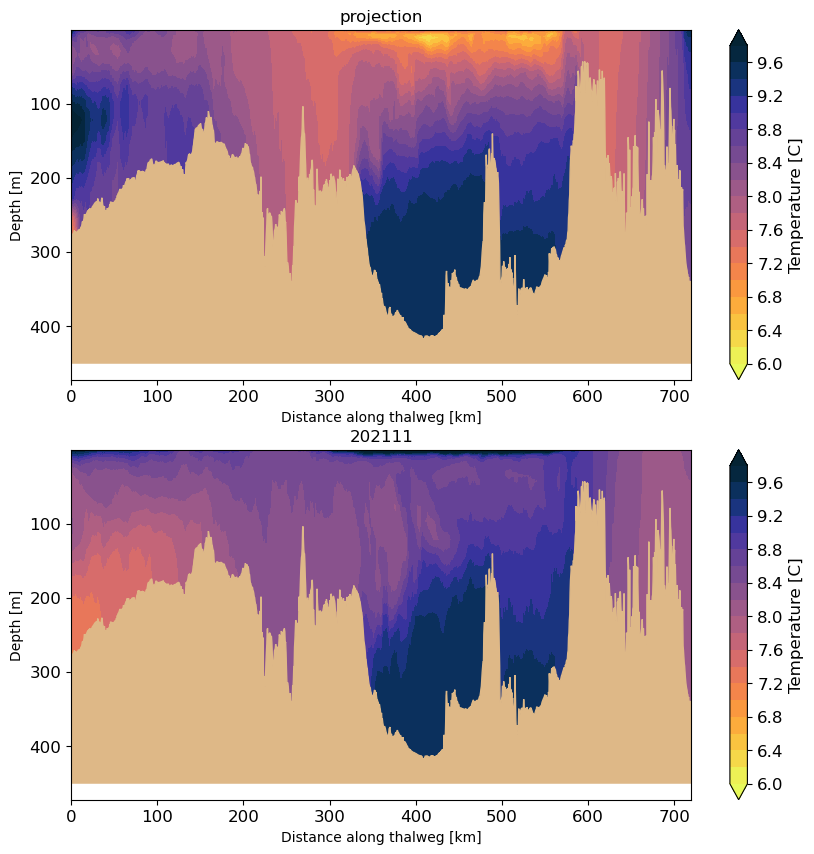

In [15]:
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(10,10))

temp_range = np.arange(6,10,0.2)

#CHANGE
tit = 'projection'
data_to_plot = change['votemper'].isel(time_counter=0).values

cbar = vis.contour_thalweg(ax1, data_to_plot, bathy, mesh, clevels=temp_range, cmap = cm.cm.thermal_r, thalweg_file=thalweg_in)
cbar.set_label('Temperature [C]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title(tit)

#original
tit = '202111'

data_to_plot = old['votemper'].isel(time_counter=0).values

cbar = vis.contour_thalweg(ax2, data_to_plot, bathy, mesh, clevels=temp_range, cmap = cm.cm.thermal_r, thalweg_file=thalweg_in)
cbar.set_label('Temperature [C]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title(tit)

## making the bdy conditions
lets go step by step over tha making of the bdy conditions on this date to see why the change is so intense <br>
specifically zoom in on the location that susan highlighted - depth 5 and 6 at xbt=192

In [16]:
def get_depth_profile(df, date_str):
    row = df.loc[df["day"] == date_str]
    prof = row.select_dtypes(include=np.number).to_numpy().squeeze()
    return prof  # shape (40,)

def oxygen_mlL_to_uM(oxygen_mlL):
    """
    Convert dissolved oxygen from mL/L to uM using molar volume.
    """

    # in seawater the 1 ml/L of oxygen is approximately equal to 44.66 umol/L
    # this is based on the molar volume of an ideal gas as STP of 22.39 L/mol
    C = 44.66
    
    # Convert mL/L to µmol/L using the in-situ molar volume
    uM = oxygen_mlL * C
    
    return uM

In [17]:
# bring in water mass fraction data (already setup for every day in that span)
ffresh = pd.read_csv('./output/inflowfraction_D_fresh.csv').drop(columns=['Unnamed: 0'])
fsouth = pd.read_csv('./output/inflowfraction_D_south.csv').drop(columns=['Unnamed: 0'])
fcuc = pd.read_csv('./output/inflowfraction_D_cuc.csv').drop(columns=['Unnamed: 0'])
foffD = pd.read_csv('./output/inflowfraction_D_offD.csv').drop(columns=['Unnamed: 0'])
foffS = pd.read_csv('./output/inflowfraction_D_offS.csv').drop(columns=['Unnamed: 0'])
fnorth = pd.read_csv('./output/inflowfraction_D_north.csv').drop(columns=['Unnamed: 0'])

In [18]:
# difference = fresh source property - south source property
S_diff_fresh_south   = 30.04-32.86 # g/kg
T_diff_fresh_south   = 10.07-9.40  # degC

# difference = CUC property - shelf source property
S_diff_south = 33.90-32.97       # g/kg
S_diff_north = 33.90-33.24       # g/kg
T_diff_south = 6.25-8.92         # degC
T_diff_north = 6.25-7.55         # degC

# columbia river flow factor based on the difference between the CMIP5 enssemble mean and the historical columbia river hydrograph in Fickin2016 (figure 5) this is our monthly scaling of flow:
monthly_factor = np.array([
    2.5,  # Jan
    2.6,  # Feb
    2.3,  # Mar
    1.4,  # Apr
    0.8,  # May
    0.5,  # Jun
    0.5,  # Jul
    0.7,  # Aug
    0.8,  # Sep
    0.9,  # Oct
    1.2,  # Nov
    2.2   # Dec
])

In [ ]:
data = xr.open_dataset('/results/forcing/LiveOcean/boundary_conditions/LiveOcean_v201905_y2019m02d18.nc')

# build an easily editable tracer dictionary 
interps18 = {
        "salt":       data["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
        "temp":       data["votemper"][0, :, :, :].values.copy(),
    }

data = xr.open_dataset('/results/forcing/LiveOcean/boundary_conditions/LiveOcean_v201905_y2019m02d19.nc')

interps19 = {
        "salt":       data["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
        "temp":       data["votemper"][0, :, :, :].values.copy(),
    }


(250.0, -10.0)

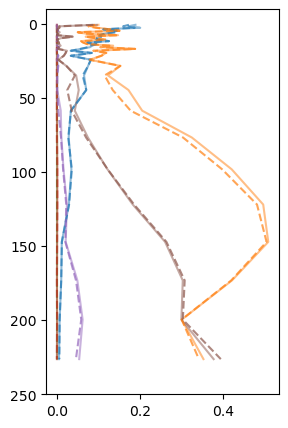

In [ ]:
# to use the profile function need to get date into the same format as the fraction dataframes
date_str = "2019-02-18"

# bring in profiles for each source water (all are being edited)
fresh_prof18 = get_depth_profile(ffresh, date_str)
south_prof18 = get_depth_profile(fsouth, date_str)
north_prof18 = get_depth_profile(fnorth, date_str)
offS_prof18  = get_depth_profile(foffS, date_str)
offD_prof18  = get_depth_profile(foffD, date_str)
cuc_prof18  = get_depth_profile(fcuc, date_str)


date_str = "2019-02-19"

# bring in profiles for each source water (all are being edited)
fresh_prof19 = get_depth_profile(ffresh, date_str)
south_prof19 = get_depth_profile(fsouth, date_str)
north_prof19 = get_depth_profile(fnorth, date_str)
offS_prof19  = get_depth_profile(foffS, date_str)
offD_prof19  = get_depth_profile(foffD, date_str)
cuc_prof19  = get_depth_profile(fcuc, date_str)


fig,ax = plt.subplots(1,1,figsize=[3,5])

ax.plot(fresh_prof18,data.deptht,alpha=0.5,color='tab:blue')
ax.plot(south_prof18,data.deptht,alpha=0.5,color='tab:orange')
ax.plot(north_prof18,data.deptht,alpha=0.5,color='tab:green')
ax.plot(offS_prof18,data.deptht,alpha=0.5,color='tab:red')
ax.plot(offD_prof18,data.deptht,alpha=0.5,color='tab:purple')
ax.plot(cuc_prof18,data.deptht,alpha=0.5,color='tab:brown')

ax.plot(fresh_prof19,data.deptht,alpha=0.7,ls='dashed',color='tab:blue')
ax.plot(south_prof19,data.deptht,alpha=0.7,ls='dashed',color='tab:orange')
ax.plot(north_prof19,data.deptht,alpha=0.7,ls='dashed',color='tab:green')
ax.plot(offS_prof19,data.deptht,alpha=0.7,ls='dashed',color='tab:red')
ax.plot(offD_prof19,data.deptht,alpha=0.7,ls='dashed',color='tab:purple')
ax.plot(cuc_prof19,data.deptht,alpha=0.7,ls='dashed',color='tab:brown')


ax.set_ylim(250,-10)

In [ ]:
# should not be any impact by upwelling since in february is not one of the upwelling change months
# move straight onto columbia river change

frac_change = monthly_factor[2 - 1]
frac_change

np.float64(2.6)

(250.0, -10.0)

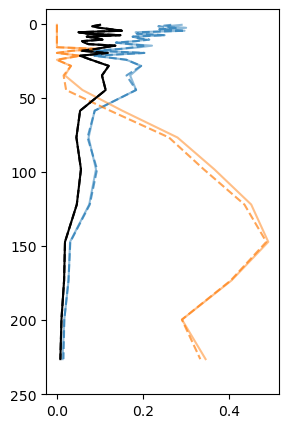

In [ ]:
requested_delta_fresh = (frac_change - 1.0) * fresh_prof18

delta_fresh18 = np.where(
        requested_delta_fresh >= 0,
        np.minimum(requested_delta_fresh, south_prof18),
        np.maximum(requested_delta_fresh, -fresh_prof18),
    )

# Updated fractions after exchange
fresh_prof18 = fresh_prof18 + delta_fresh18
south_prof18 = south_prof18 - delta_fresh18



requested_delta_fresh = (frac_change - 1.0) * fresh_prof19

delta_fresh19 = np.where(
        requested_delta_fresh >= 0,
        np.minimum(requested_delta_fresh, south_prof19),
        np.maximum(requested_delta_fresh, -fresh_prof19),
    )

# Updated fractions after exchange
fresh_prof19 = fresh_prof19 + delta_fresh19
south_prof19 = south_prof19 - delta_fresh19



fig,ax = plt.subplots(1,1,figsize=[3,5])

ax.plot(fresh_prof18,data.deptht,alpha=0.5,color='tab:blue')
ax.plot(south_prof18,data.deptht,alpha=0.5,color='tab:orange')
ax.plot(delta_fresh18,data.deptht,'k')


ax.plot(fresh_prof19,data.deptht,alpha=0.7,ls='dashed',color='tab:blue')
ax.plot(south_prof19,data.deptht,alpha=0.7,ls='dashed',color='tab:orange')
ax.plot(delta_fresh18,data.deptht,'k--')



ax.set_ylim(250,-10)

Text(0.5, 0, 'temperature change')

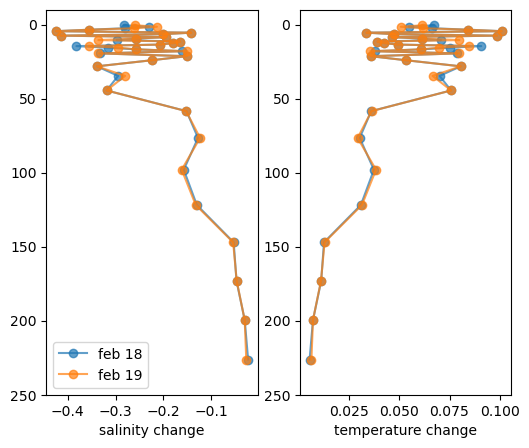

In [ ]:
# property change based on fraction change

# make copy of interps
interps18_columbia = copy.deepcopy(interps18)
interps19_columbia = copy.deepcopy(interps19)

fig, ax = plt.subplots(1,2,figsize=[6,5])

delta_S_profile   = delta_fresh18 * S_diff_fresh_south
delta_T_profile   = delta_fresh18 * T_diff_fresh_south

interps18_columbia["salt"] = interps18_columbia["salt"] + delta_S_profile[:, None, None]
interps18_columbia["temp"] = interps18_columbia["temp"] + delta_T_profile[:, None, None]

ax[0].plot(delta_S_profile,data.deptht,label='feb 18',alpha=0.7,marker='o')
ax[1].plot(delta_T_profile,data.deptht,alpha=0.7,marker='o')

delta_S_profile   = delta_fresh19 * S_diff_fresh_south
delta_T_profile   = delta_fresh19 * T_diff_fresh_south

interps19_columbia["salt"] = interps19_columbia["salt"] + delta_S_profile[:, None, None]
interps19_columbia["temp"] = interps19_columbia["temp"] + delta_T_profile[:, None, None]

ax[0].plot(delta_S_profile,data.deptht,label='feb 19',alpha=0.7,marker='o')
ax[1].plot(delta_T_profile,data.deptht,alpha=0.7,marker='o')

ax[0].set_ylim(250,-10)
ax[1].set_ylim(250,-10)

ax[0].legend()

ax[0].set_xlabel("salinity change")
ax[1].set_xlabel("temperature change")


Text(0.5, 0, 'temperature change')

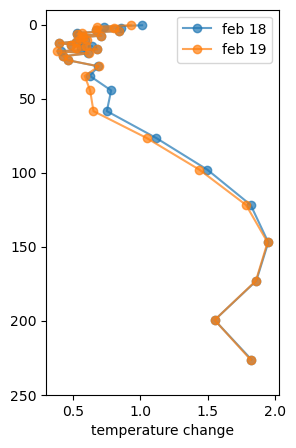

In [ ]:
# now look at the property change

# make copy of interps
interps18_prop = copy.deepcopy(interps18)
interps19_prop = copy.deepcopy(interps19)
interps18_combine = copy.deepcopy(interps18_columbia)
interps19_combine = copy.deepcopy(interps19_columbia)

fig,ax = plt.subplots(1,1,figsize=[3,5])

delta_T_profile = (
        fresh_prof18 * 2.82
        + offS_prof18 * 2.89
        + north_prof18 * 2.62
        + south_prof18 * 2.62
        + offD_prof18 * 2.05
        + cuc_prof18 * 2.05
    )

ax.plot(delta_T_profile,data.deptht,label='feb 18',alpha=0.7,marker='o')

interps18_prop["temp"]  += delta_T_profile[:, None, None]
interps18_combine["temp"]  += delta_T_profile[:, None, None]

# now look at the property change

delta_T_profile = (
        fresh_prof19 * 2.82
        + offS_prof19 * 2.89
        + north_prof19 * 2.62
        + south_prof19 * 2.62
        + offD_prof19 * 2.05
        + cuc_prof19 * 2.05
    )

ax.plot(delta_T_profile,data.deptht,label='feb 19',alpha=0.7,marker='o')

interps19_prop["temp"]  += delta_T_profile[:, None, None]
interps19_combine["temp"]  += delta_T_profile[:, None, None]


ax.set_ylim(250,-10)
ax.legend()
ax.set_xlabel("temperature change")

In [ ]:
# apply stabilization to the combined result
interps18_stab = copy.deepcopy(interps18_combine)
interps19_stab = copy.deepcopy(interps19_combine)

sigma = gsw.sigma0(interps18_stab['salt'], interps18_stab['temp']) # need density first
sigma, interps18_stab = convect(sigma, interps18_stab)
interps18_stab = stabilize(sigma, interps18_stab)

sigma = gsw.sigma0(interps19_stab['salt'], interps19_stab['temp']) # need density first
sigma, interps19_stab = convect(sigma, interps19_stab)
interps19_stab = stabilize(sigma, interps19_stab)

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

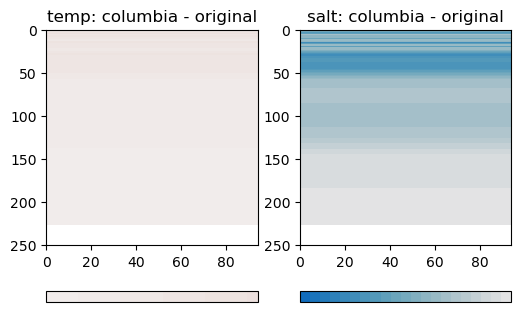

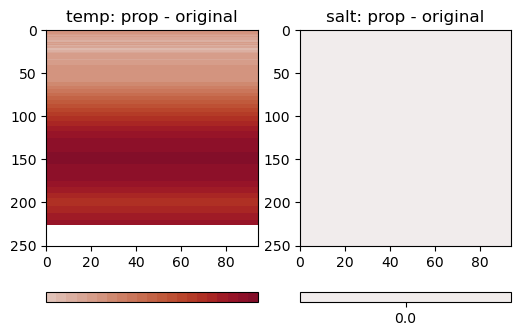

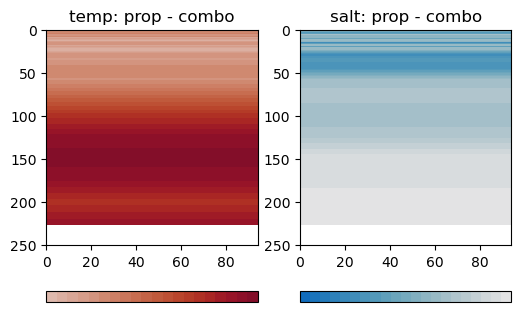

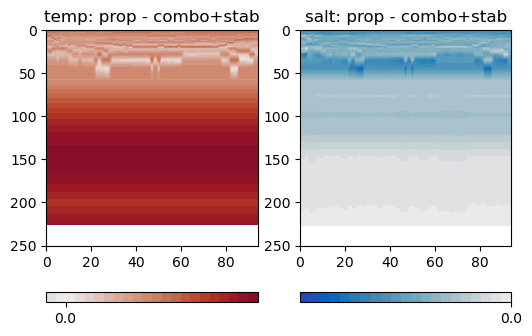

In [ ]:
# lets look at the difference between each of these and the original boundary conditions
# for the 18th first

X, Y = np.meshgrid(data.xbT[0:95].values,data.deptht.values)
tracers = ['temp','salt']


# columbia river
fig, ax = plt.subplots(1,2,figsize=[6,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}: columbia - original"
    ax[i].set_title(title)

    values = interps18_columbia[tracers[i]][:,0,0:95] - interps18[tracers[i]][:,0,0:95]
    if tracers[i]=='temp':
        vmin,vmax = -2.5,2.5
    elif tracers[i]=='salt':
        vmin,vmax = -0.7,0.7
    else:
        vmin, vmax = -np.max(abs(values)), np.max(abs(values))

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.balance,vmin=vmin,vmax=vmax)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[vmin,0,vmax])
    ax[i].set_ylim([250,0])

plt.tight_layout

# properties
fig, ax = plt.subplots(1,2,figsize=[6,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}: prop - original"
    ax[i].set_title(title)

    values = interps18_prop[tracers[i]][:,0,0:95] - interps18[tracers[i]][:,0,0:95]
    if tracers[i]=='temp':
        vmin,vmax = -2.5,2.5
    elif tracers[i]=='salt':
        vmin,vmax = -0.7,0.7
    else:
        vmin, vmax = -np.max(abs(values)), np.max(abs(values))

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.balance,vmin=vmin,vmax=vmax)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[vmin,0,vmax])
    ax[i].set_ylim([250,0])

plt.tight_layout


# combined
fig, ax = plt.subplots(1,2,figsize=[6,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}: prop - combo"
    ax[i].set_title(title)

    values = interps18_combine[tracers[i]][:,0,0:95] - interps18[tracers[i]][:,0,0:95]
    if tracers[i]=='temp':
        vmin,vmax = -2.5,2.5
    elif tracers[i]=='salt':
        vmin,vmax = -0.7,0.7
    else:
        vmin, vmax = -np.max(abs(values)), np.max(abs(values))

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.balance,vmin=vmin,vmax=vmax)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[vmin,0,vmax])
    ax[i].set_ylim([250,0])

plt.tight_layout


# combo_stab
fig, ax = plt.subplots(1,2,figsize=[6,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}: prop - combo+stab"
    ax[i].set_title(title)

    values = interps18_stab[tracers[i]][:,0,0:95] - interps18[tracers[i]][:,0,0:95]
    if tracers[i]=='temp':
        vmin,vmax = -2.5,2.5
    elif tracers[i]=='salt':
        vmin,vmax = -0.7,0.7
    else:
        vmin, vmax = -np.max(abs(values)), np.max(abs(values))

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.balance,vmin=vmin,vmax=vmax)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[vmin,0,vmax])
    ax[i].set_ylim([250,0])

plt.tight_layout

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

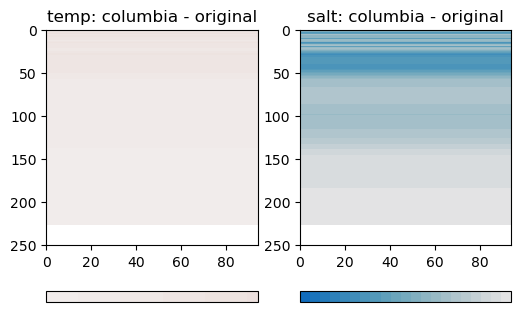

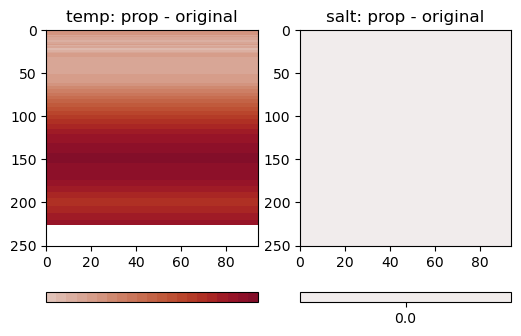

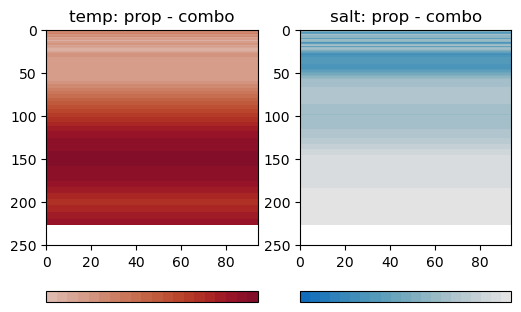

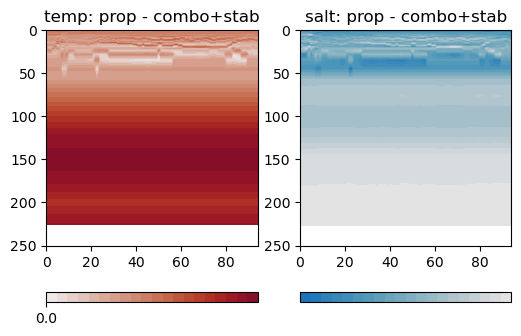

In [ ]:
# lets look at the difference between each of these and the original boundary conditions
# for the 19th first

X, Y = np.meshgrid(data.xbT[0:95].values,data.deptht.values)
tracers = ['temp','salt']


# columbia river
fig, ax = plt.subplots(1,2,figsize=[6,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}: columbia - original"
    ax[i].set_title(title)

    values = interps19_columbia[tracers[i]][:,0,0:95] - interps19[tracers[i]][:,0,0:95]
    if tracers[i]=='temp':
        vmin,vmax = -2.5,2.5
    elif tracers[i]=='salt':
        vmin,vmax = -0.7,0.7
    else:
        vmin, vmax = -np.max(abs(values)), np.max(abs(values))

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.balance,vmin=vmin,vmax=vmax)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[vmin,0,vmax])
    ax[i].set_ylim([250,0])

plt.tight_layout

# properties
fig, ax = plt.subplots(1,2,figsize=[6,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}: prop - original"
    ax[i].set_title(title)

    values = interps19_prop[tracers[i]][:,0,0:95] - interps19[tracers[i]][:,0,0:95]
    if tracers[i]=='temp':
        vmin,vmax = -2.5,2.5
    elif tracers[i]=='salt':
        vmin,vmax = -0.7,0.7
    else:
        vmin, vmax = -np.max(abs(values)), np.max(abs(values))

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.balance,vmin=vmin,vmax=vmax)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[vmin,0,vmax])
    ax[i].set_ylim([250,0])

plt.tight_layout


# combined
fig, ax = plt.subplots(1,2,figsize=[6,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}: prop - combo"
    ax[i].set_title(title)

    values = interps19_combine[tracers[i]][:,0,0:95] - interps19[tracers[i]][:,0,0:95]
    if tracers[i]=='temp':
        vmin,vmax = -2.5,2.5
    elif tracers[i]=='salt':
        vmin,vmax = -0.7,0.7
    else:
        vmin, vmax = -np.max(abs(values)), np.max(abs(values))

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.balance,vmin=vmin,vmax=vmax)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[vmin,0,vmax])
    ax[i].set_ylim([250,0])

plt.tight_layout


# combo_stab
fig, ax = plt.subplots(1,2,figsize=[6,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}: prop - combo+stab"
    ax[i].set_title(title)

    values = interps19_stab[tracers[i]][:,0,0:95] - interps19[tracers[i]][:,0,0:95]
    if tracers[i]=='temp':
        vmin,vmax = -2.5,2.5
    elif tracers[i]=='salt':
        vmin,vmax = -0.7,0.7
    else:
        vmin, vmax = -np.max(abs(values)), np.max(abs(values))

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.balance,vmin=vmin,vmax=vmax)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[vmin,0,vmax])
    ax[i].set_ylim([250,0])

plt.tight_layout

In [ ]:
# bring in your boundary file and see if it looks similar
data = xr.open_dataset('/ocean/rbeutel/MOAD/analysis-becca/projections/output/bdy_AllChange/LiveOcean_v201905_y2019m02d18.nc')

# build an easily editable tracer dictionary 
output18 = {
        "salt":       data["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
        "temp":       data["votemper"][0, :, :, :].values.copy(),
    }

data = xr.open_dataset('/ocean/rbeutel/MOAD/analysis-becca/projections/output/bdy_AllChange/LiveOcean_v201905_y2019m02d19.nc')

output19 = {
        "salt":       data["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
        "temp":       data["votemper"][0, :, :, :].values.copy(),
    }

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

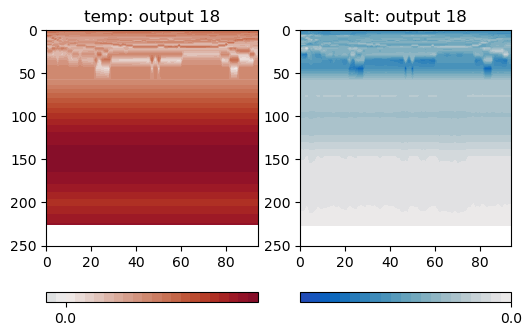

In [ ]:
fig, ax = plt.subplots(1,2,figsize=[6,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}: output 18"
    ax[i].set_title(title)

    values = output18[tracers[i]][:,0,0:95] - interps18[tracers[i]][:,0,0:95]
    if tracers[i]=='temp':
        vmin,vmax = -2.5,2.5
    elif tracers[i]=='salt':
        vmin,vmax = -0.7,0.7
    else:
        vmin, vmax = -np.max(abs(values)), np.max(abs(values))

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.balance,vmin=vmin,vmax=vmax)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[vmin,0,vmax])
    ax[i].set_ylim([250,0])

plt.tight_layout

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

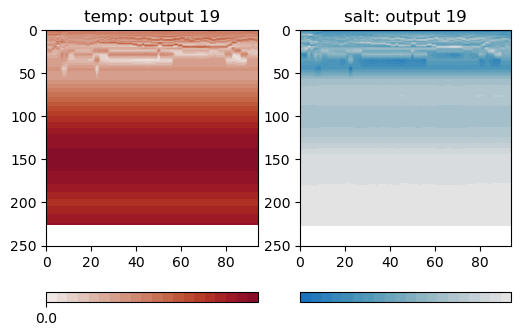

In [ ]:
fig, ax = plt.subplots(1,2,figsize=[6,4])

for i in range(len(tracers)):

    title=f"{tracers[i]}: output 19"
    ax[i].set_title(title)

    values = output19[tracers[i]][:,0,0:95] - interps19[tracers[i]][:,0,0:95]
    if tracers[i]=='temp':
        vmin,vmax = -2.5,2.5
    elif tracers[i]=='salt':
        vmin,vmax = -0.7,0.7
    else:
        vmin, vmax = -np.max(abs(values)), np.max(abs(values))

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.balance,vmin=vmin,vmax=vmax)
    fig.colorbar(cs, ax=ax[i], location='bottom',ticks=[vmin,0,vmax])
    ax[i].set_ylim([250,0])

plt.tight_layout

## new error

In [4]:
err = xr.open_dataset("/ocean/rbeutel/MOAD/analysis-becca/projections/output.abort.nc")
err

<xarray.Dataset> Size: 413MB
Dimensions:       (time_counter: 1, deptht: 40, y: 898, x: 398)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 8B 2019-02-12T00:00:39
  * deptht        (deptht) float32 160B 0.5 1.5 2.5 3.5 ... 387.6 414.5 441.5
    nav_lon       (y, x) float32 1MB ...
    nav_lat       (y, x) float32 1MB ...
Dimensions without coordinates: y, x
Data variables: (12/14)
    vosaline      (time_counter, deptht, y, x) float32 57MB ...
    votemper      (time_counter, deptht, y, x) float32 57MB ...
    sossheig      (time_counter, y, x) float32 1MB ...
    vozocrtx      (time_counter, deptht, y, x) float32 57MB ...
    vomecrty      (time_counter, deptht, y, x) float32 57MB ...
    vovecrtz      (time_counter, deptht, y, x) float32 57MB ...
    ...            ...
    soshfldo      (time_counter, y, x) float32 1MB ...
    soicecov      (time_counter, y, x) float32 1MB ...
    sozotaux      (time_counter, y, x) float32 1MB ...
    sometauy      (time_counter, y, x) float32 1MB ...
    vovvldep      (time_counter, deptht, y, x) float32 57MB ...
    vovvle3t      (time_counter, deptht, y, x) float32 57MB ...
Attributes:
    Conventions:  CF-1.1
    production:   An IPSL model
    TimeStamp:    03/07/2026 14:34:46 -0700
    file_name:    output.abort.nc

In [5]:
ssh = err.sossheig.values[0,:,:]
ssh

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(898, 398), dtype=float32)

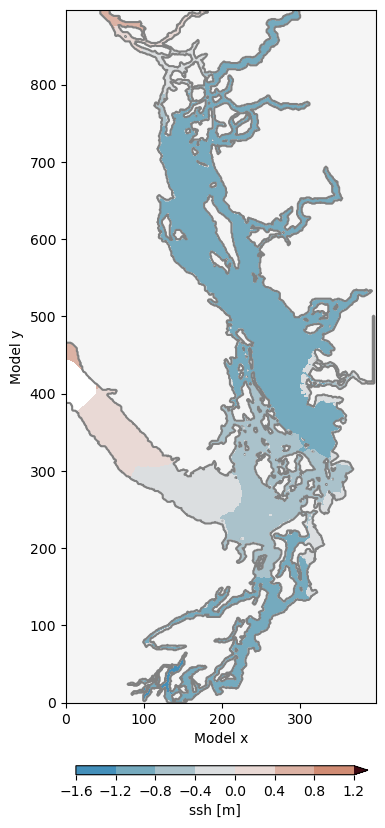

In [6]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask201702.nc')
grid = xr.open_dataset("/home/sallen/MEOPAR/grid/bathymetry_202108.nc", mask_and_scale=False)

# Make plot area
fig, ax = plt.subplots(figsize=(4, 9))

# Depth
c = ax.contourf(
    grid.x, grid.y, ssh, vmax=3, vmin=-3,
    cmap=cm.cm.balance, extend='max', zorder=1,
)
cax = fig.add_axes([0.15, 0.03, 0.73, 0.01])
fig.colorbar(c, cax=cax, orientation='horizontal',label='ssh [m]')

ax.set_xlabel("Model x")
ax.set_ylabel("Model y")

# Draw coastline
ax.contourf(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='whitesmoke')
ax.contour(mesh.tmask[0, 0, ...], levels=[-0.01, 0.01], colors='gray')

In [ ]:
# lets compare boundary condition files on 2018/01/01

original = xr.open_dataset('/results/forcing/LiveOcean/boundary_conditions/LiveOcean_v201905_y2018m01d01.nc')
original

In [ ]:
v2 = xr.open_dataset('/ocean/rbeutel/MOAD/analysis-becca/projections/output/bdy_SouthChange/LiveOcean_v201905_y2018m01d01.nc')
v2

<xarray.Dataset> Size: 2MB
Dimensions:       (time_counter: 1, deptht: 40, yb: 1, xbT: 950)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 8B 2018-01-01T12:00:00
  * deptht        (deptht) float64 320B 0.5 1.5 2.5 3.5 ... 387.6 414.5 441.5
  * yb            (yb) int64 8B 1
  * xbT           (xbT) int64 8kB 0 1 2 3 4 5 6 ... 943 944 945 946 947 948 949
Data variables:
    vosaline      (time_counter, deptht, yb, xbT) float64 304kB ...
    votemper      (time_counter, deptht, yb, xbT) float64 304kB ...
    NO3           (time_counter, deptht, yb, xbT) float64 304kB ...
    Si            (time_counter, deptht, yb, xbT) float64 304kB ...
    OXY           (time_counter, deptht, yb, xbT) float64 304kB ...
    DIC           (time_counter, deptht, yb, xbT) float64 304kB ...
    TA            (time_counter, deptht, yb, xbT) float64 304kB ...
Attributes:
    acknowledgements:      Live Ocean http://faculty.washington.edu/pmacc/LO/...
    creator_email:         sallen@eoas.ubc.ca
    creator_name:          Salish Sea MEOPAR Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    summary:               Temperature, Salinity, Nitrate, Oxygen, DIC and TA...
    source:                http://nbviewer.jupyter.org/urls/bitbucket.org/sal...
    history:               [2019-06-10] File creation. | edited for 2100, sou...

In [ ]:
# build an easily editable tracer dictionary 
_original = {
        "salt":       original["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
        "temp":       original["votemper"][0, :, :, :].values.copy(),
    }


_v2 = {
        "salt":       v2["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
        "temp":       v2["votemper"][0, :, :, :].values.copy(),
    }

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

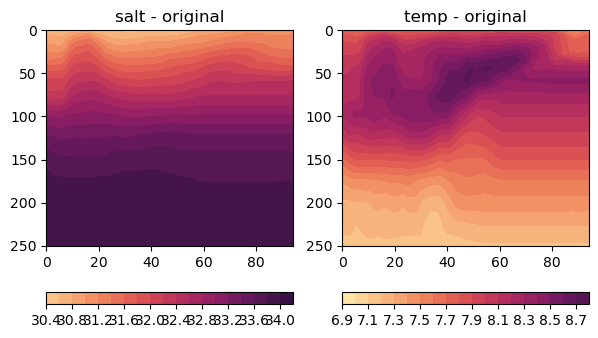

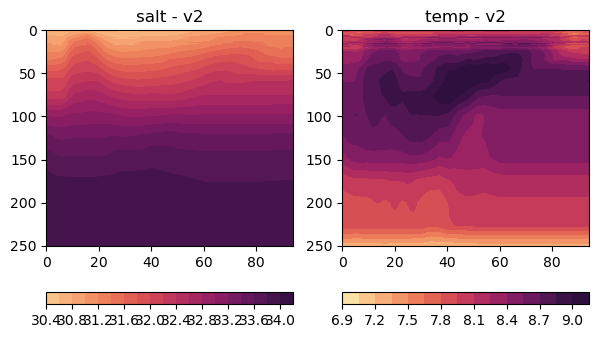

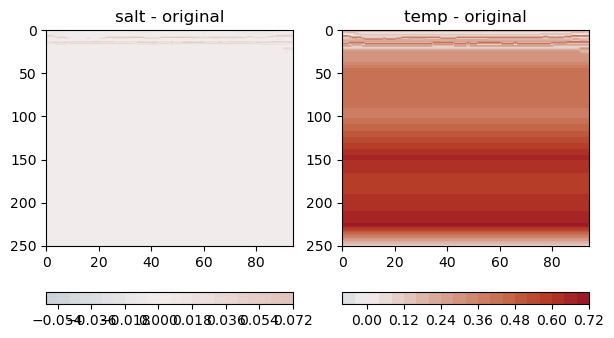

In [ ]:

X, Y = np.meshgrid(data.xbT[0:95].values,data.deptht.values)
tracers = ['salt','temp']
vmin = [30,6.9]
vmax = [34.2,9]


# original
fig, ax = plt.subplots(1,2,figsize=[7,4])

for i in range(len(tracers)):

    title=f"{tracers[i]} - original"
    ax[i].set_title(title)

    values = _original[tracers[i]][:,0,0:95]

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.matter,vmin=vmin[i],vmax=vmax[i])
    fig.colorbar(cs, ax=ax[i], location='bottom')

plt.tight_layout


# v2
fig, ax = plt.subplots(1,2,figsize=[7,4])

for i in range(len(tracers)):

    title=f"{tracers[i]} - v2"
    ax[i].set_title(title)

    values = _v2[tracers[i]][:,0,0:95]

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.matter,vmin=vmin[i],vmax=vmax[i])
    fig.colorbar(cs, ax=ax[i], location='bottom')

plt.tight_layout

# v2-orignal
vmax = [0.5,1]
fig, ax = plt.subplots(1,2,figsize=[7,4])

for i in range(len(tracers)):

    title=f"{tracers[i]} - original"
    ax[i].set_title(title)

    values = _v2[tracers[i]][:,0,0:95] - _original[tracers[i]][:,0,0:95]

    cs = ax[i].contourf(X,Y,values,levels=20,cmap=cm.cm.balance,vmin=-vmax[i],vmax=vmax[i])
    fig.colorbar(cs, ax=ax[i], location='bottom')

plt.tight_layout

In [ ]:
# check that tracers extend to the bottom

_original['vosaline'][:,0,0:95]

In [ ]:
_v2['vosaline'][:,0,0:95]
